## Modelling

- Data prep
- Null Model
- Accessibility
- Controls
- Interactions
- Well-being models
- Model diagnostics

In [1]:
import sys
sys.path.append("..")
from tqdm import tqdm
tqdm.pandas()
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

In [2]:
model_data_df = pd.read_parquet("../data/full_variable_df.parquet")
model_data_df['total_breadth'] = model_data_df['phys_breadth'] + model_data_df['digi_breadth']
model_data_df['total_depth'] = model_data_df['phys_depth'] + model_data_df['digi_depth']

# Normalise to 0–1
for var in ['total_breadth', 'total_depth']:
    model_data_df[f'{var}_norm'] = (
        (model_data_df[var] - model_data_df[var].min()) /
        (model_data_df[var].max() - model_data_df[var].min())
    )

# Intensity
model_data_df['intensity'] = (
    model_data_df['total_breadth_norm'] *
    model_data_df['total_depth_norm']
)

# Standardise proximity
model_data_df['prox_z'] = (
    model_data_df['LAD_agg_proximity'] -
    model_data_df['LAD_agg_proximity'].mean()
) / model_data_df['LAD_agg_proximity'].std()

print(model_data_df[['total_breadth', 'total_depth', 'intensity', 'prox_z']].describe())

       total_breadth  total_depth  intensity        prox_z
count       171748.0     171748.0   171748.0  1.717480e+05
mean       10.170587   167.541293   0.027573  5.907813e-17
std         5.631196   110.966911   0.028916  1.000000e+00
min              0.0          0.0        0.0 -2.780960e+00
25%              6.0         85.0   0.006942 -6.071527e-01
50%             10.0        156.0   0.019724  1.217170e-02
75%             14.0        232.0    0.03911  6.002261e-01
max             39.0       1976.0   0.974359  1.840708e+00


### Data Prep

#### Missing Data

In [3]:
# Missing values summary
missing_summary = model_data_df.isnull().sum().to_frame(name='missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(model_data_df)) * 100

print("\nMissing Data Summary:")
print(missing_summary.sort_values(by='missing_pct', ascending=False))


Missing Data Summary:
                      missing_count  missing_pct
EDUCAT4                       49783    28.986073
NSSEC_5                       23893    13.911661
ETHNIC_NET_Safeguard           6273     3.652444
WELLB4_rev                     5911     3.441670
wellbeing                      3494     2.034376
SEX                            2947     1.715886
AGEBAND                        2820     1.641941
LAD23CD                           0     0.000000
intensity                         0     0.000000
total_depth_norm                  0     0.000000
total_breadth_norm                0     0.000000
total_depth                       0     0.000000
total_breadth                     0     0.000000
LAD_agg_proximity                 0     0.000000
LAD23NM                           0     0.000000
ArchYcserial                      0     0.000000
phys_breadth                      0     0.000000
WELLB3                            0     0.000000
WELLB2                            0     0.0000

In [4]:
# Fill missing as new category
model_data_df['EDUCAT4_filled'] = model_data_df['EDUCAT4'].fillna(-1)
model_data_df['NSSEC_5_filled'] = model_data_df['NSSEC_5'].fillna(-1)

# Convert to categorical
model_data_df['EDUCAT4_filled'] = model_data_df['EDUCAT4_filled'].astype('category')
model_data_df['NSSEC_5_filled'] = model_data_df['NSSEC_5_filled'].astype('category')

In [ ]:
# Drop remaining missing values
model_data_df_clean = model_data_df.dropna(subset=[
    'SEX', #1 Female, 2 Male
    'AGEBAND',
    'ETHNIC_NET_Safeguard',
    'wellbeing'
])

#### Numeric Vars Distribution

In [6]:
# Select key numeric variables
numeric_vars = [
    'phys_breadth', 'digi_breadth', 'total_breadth',
    'phys_depth', 'digi_depth', 'total_depth',
    'wellbeing',
    'LAD_agg_proximity'
]

desc_stats = model_data_df[numeric_vars].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

print("\nDescriptive Statistics:")
print(desc_stats)


Descriptive Statistics:
       phys_breadth  digi_breadth  total_breadth  phys_depth  digi_depth  \
count      171748.0      171748.0       171748.0    171748.0    171748.0   
mean       4.259741      5.910846      10.170587   37.083058  130.458235   
std        3.063173      3.336428       5.631196   41.783655   93.417002   
min             0.0           0.0            0.0         0.0         0.0   
1%              0.0           0.0            0.0         0.0         0.0   
5%              0.0           1.0            2.0         0.0         2.0   
50%             4.0           6.0           10.0        20.0       119.0   
95%            10.0          11.0           20.0       116.0       299.0   
99%            13.0          14.0           24.0       170.0       400.0   
max            24.0          16.0           39.0      1144.0       832.0   

       total_depth  wellbeing  LAD_agg_proximity  
count     171748.0   168254.0      171748.000000  
mean    167.541293   6.826392       


Skewness:
phys_depth           2.497252
total_depth          0.970584
digi_depth           0.868957
phys_breadth         0.852494
total_breadth        0.398869
digi_breadth         0.179672
LAD_agg_proximity   -0.096632
wellbeing           -0.614994
dtype: Float64
phys_depth: 8.77% zeros
digi_depth: 4.48% zeros
total_depth: 2.51% zeros


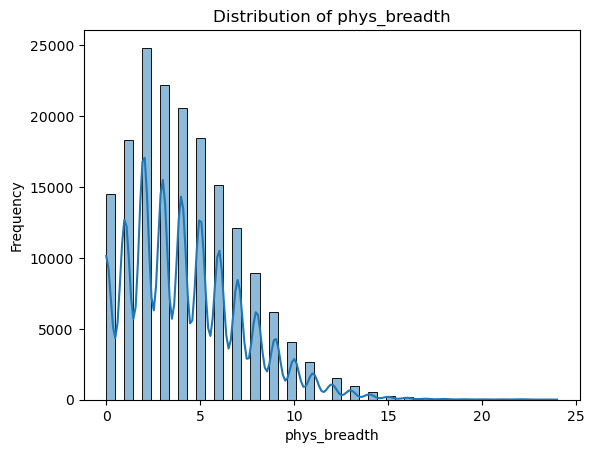

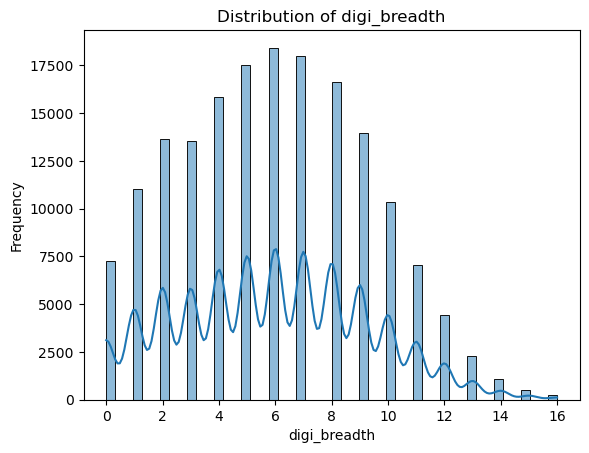

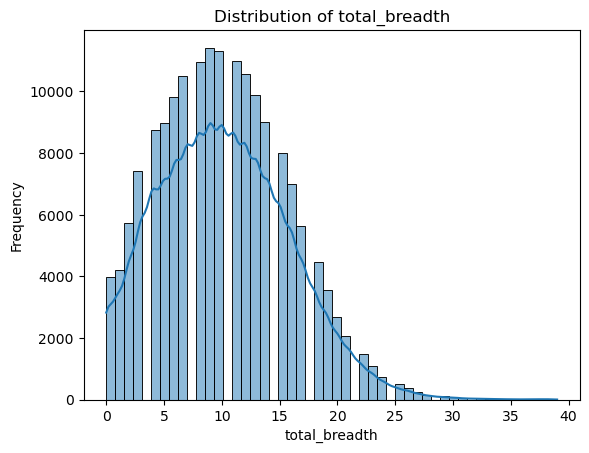

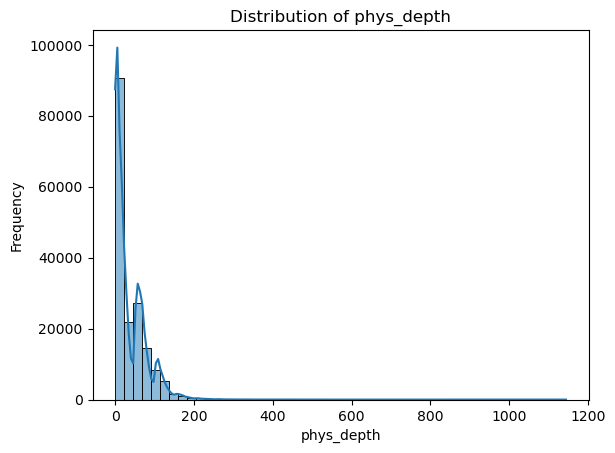

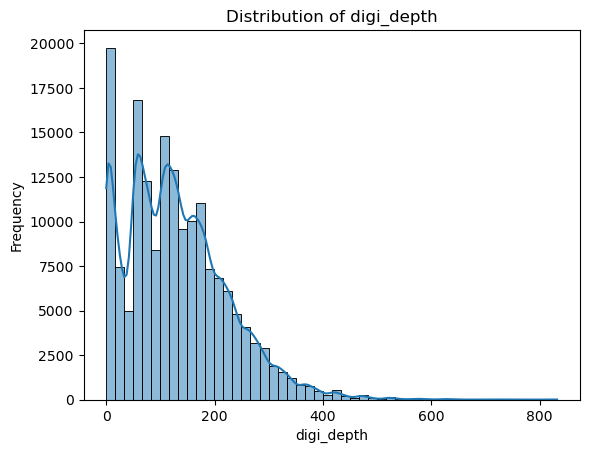

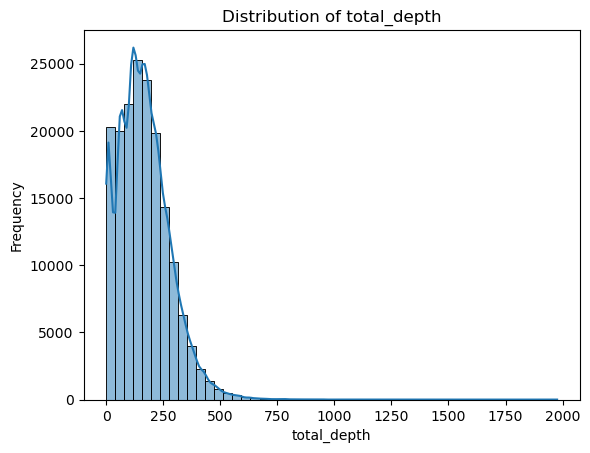

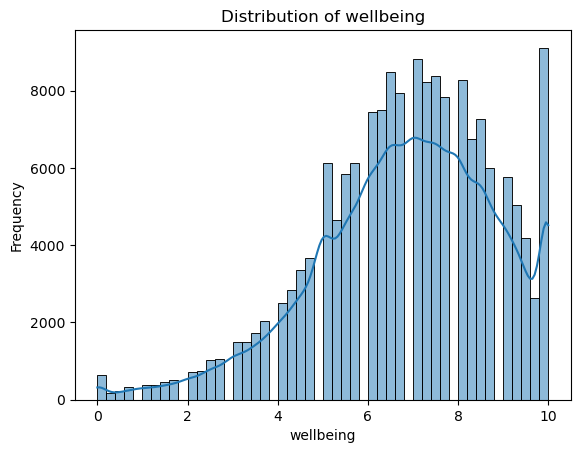

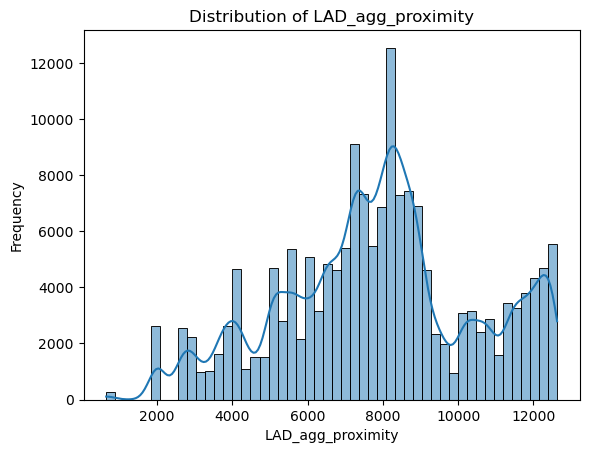

In [7]:
skewness = model_data_df[numeric_vars].skew()
print("\nSkewness:")
print(skewness.sort_values(ascending=False))


# Check for zero inflation 
for var in ['phys_depth', 'digi_depth', 'total_depth']:
    zero_pct = (model_data_df[var] == 0).mean() * 100
    print(f"{var}: {zero_pct:.2f}% zeros")


# Plot distributions
for var in numeric_vars:
    plt.figure()
    sns.histplot(model_data_df[var].dropna(), bins=50, kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

#### Numerical Var Correlations

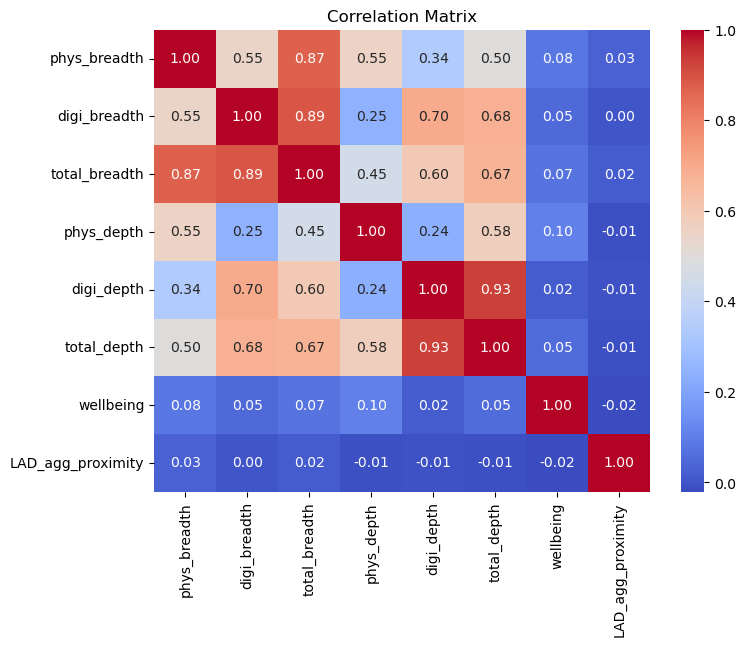

In [8]:
corr_matrix = model_data_df[numeric_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### Categorical Vars Distribution

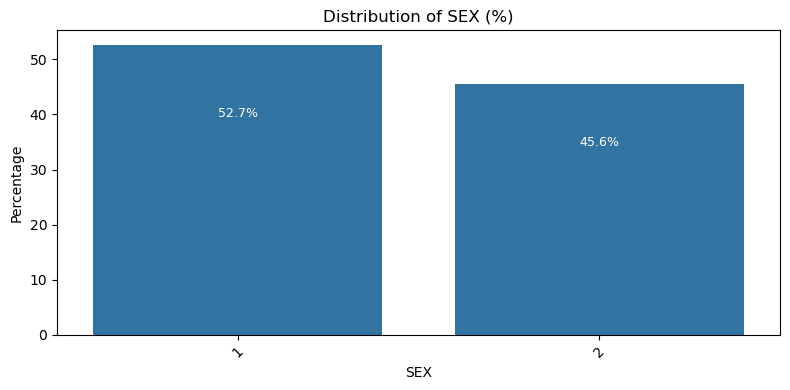

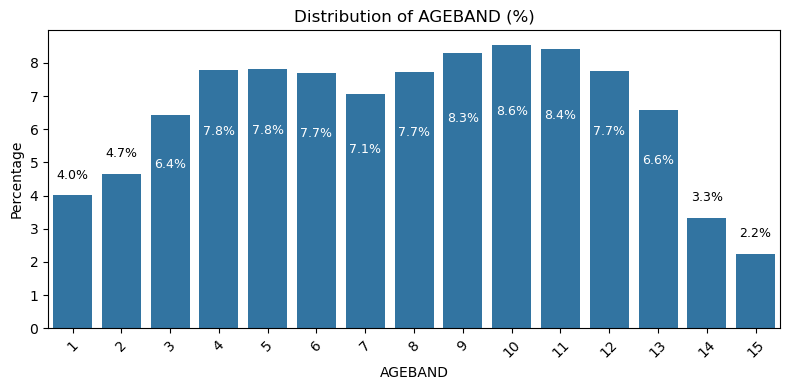

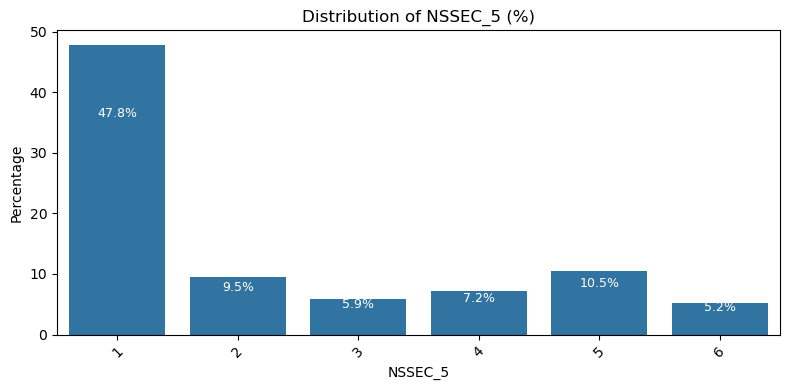

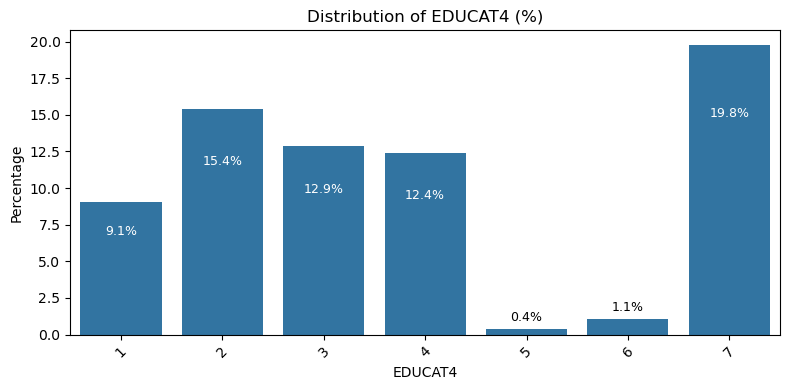

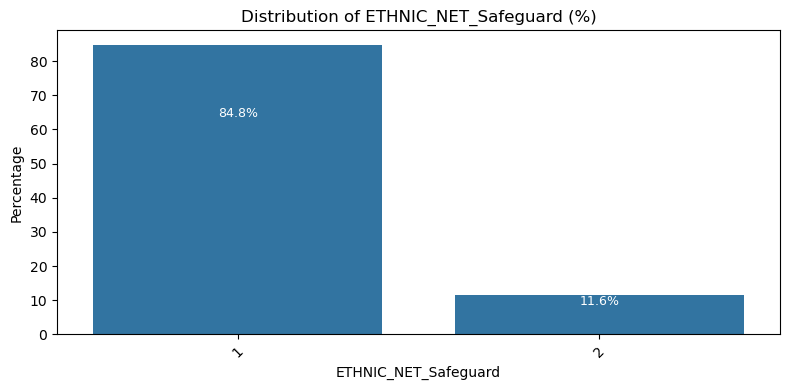

In [9]:
categorical_vars = ['SEX', 'AGEBAND', 'NSSEC_5', 'EDUCAT4', 'ETHNIC_NET_Safeguard']

for var in categorical_vars:
    plt.figure(figsize=(8, 4))
    
    proportions = model_data_df[var].value_counts(normalize=True, dropna=False) * 100
    
    sns.barplot(x=proportions.index, y=proportions.values)
    
    plt.title(f'Distribution of {var} (%)')
    plt.xlabel(var)
    plt.ylabel('Percentage')
    
    # Add labels on bars
    for i, val in enumerate(proportions[proportions.index.dropna()].sort_index().values):
        if val > 5:
            plt.text(i, val*0.75, f"{val:.1f}%", ha='center', fontsize=9, color="#FFFFFF")
        else:
            plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontsize=9, color="#000000")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Clean Model Data

In [10]:
select_vars = [
    # DVs
    'total_depth', 'phys_depth', 'digi_depth',
    'total_breadth', 'phys_breadth', 'digi_breadth',

    # IV
    'prox_z',

    # Controls
    'SEX',
    'AGEBAND',
    'ETHNIC_NET_Safeguard',
    'EDUCAT4_filled',
    'NSSEC_5_filled',

    # Grouping
    'LAD23CD'
]

final_vars = [
    # DVs
    'total_depth', 'phys_depth', 'digi_depth',
    'total_breadth', 'phys_breadth', 'digi_breadth',

    # IV
    'prox_z',

    # Controls
    'SEX',
    'AGE',
    'ETH',
    'EDU',
    'SES',

    # Grouping
    'LAD23CD'
]

clean_model_df = model_data_df.dropna(subset=[
                'SEX', 'AGEBAND', 'ETHNIC_NET_Safeguard'
            ]).loc[:,select_vars].copy()
clean_model_df.columns = final_vars

categorical_vars = [
    'SEX',
    'AGE',
    'ETH',
    'EDU',
    'SES'
]

for var in categorical_vars:
    clean_model_df[var] = clean_model_df[var].astype('category')

print( clean_model_df.info() )
clean_model_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 162510 entries, 0 to 171747
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   total_depth    162510 non-null  Int64   
 1   phys_depth     162510 non-null  Int64   
 2   digi_depth     162510 non-null  Int64   
 3   total_breadth  162510 non-null  Int64   
 4   phys_breadth   162510 non-null  Int64   
 5   digi_breadth   162510 non-null  Int64   
 6   prox_z         162510 non-null  float64 
 7   SEX            162510 non-null  category
 8   AGE            162510 non-null  category
 9   ETH            162510 non-null  category
 10  EDU            162510 non-null  category
 11  SES            162510 non-null  category
 12  LAD23CD        162510 non-null  object  
dtypes: Int64(6), category(5), float64(1), object(1)
memory usage: 12.9+ MB
None


,total_depth,phys_depth,digi_depth,total_breadth,phys_breadth,digi_breadth,prox_z,SEX,AGE,ETH,EDU,SES,LAD23CD
0,193,7,186,11,4,7,-0.494516,1,4,1,1,1,E08000011
1,16,13,3,3,2,1,-1.157271,2,5,1,7,1,E07000108
2,308,92,216,23,11,12,1.732098,2,3,1,1,-1,E09000030
3,206,9,197,14,5,9,-1.395713,2,3,1,7,1,E07000148
4,169,30,139,18,9,9,-1.395713,1,2,1,4,1,E07000148


--- Proportions for SEX ---
SEX
1    53.570857
2    46.429143
Name: proportion, dtype: float64




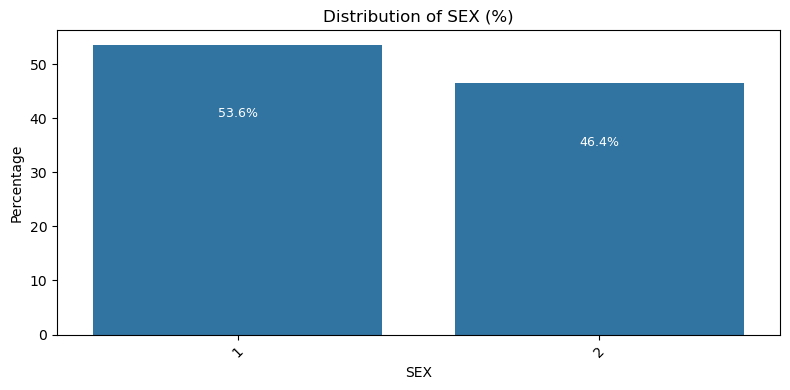




--- Proportions for AGE ---
AGE
10    8.802535
11    8.686850
9     8.480094
12    8.012430
8     7.854286
5     7.851825
4     7.801366
6     7.733678
7     7.140484
13    6.822965
3     6.446988
2     4.628638
1     4.007753
14    3.437327
15    2.292782
Name: proportion, dtype: float64




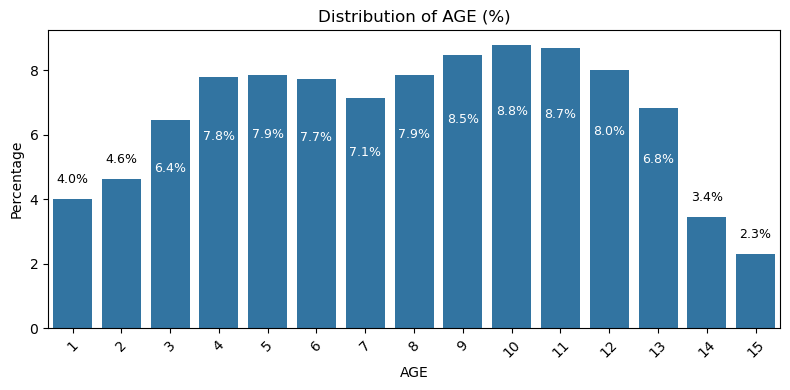




--- Proportions for ETH ---
ETH
1    88.088118
2    11.911882
Name: proportion, dtype: float64




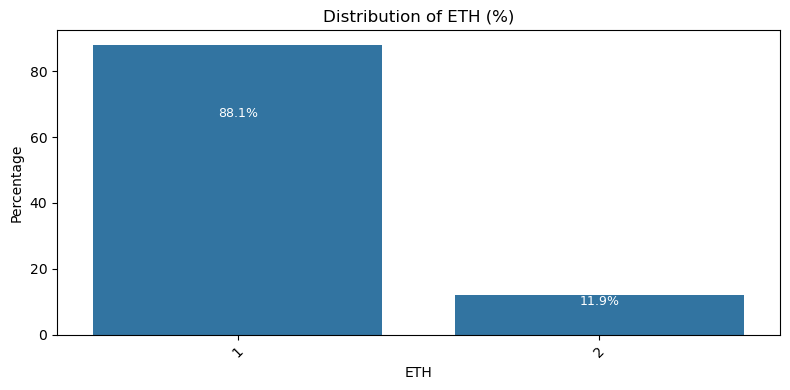




--- Proportions for EDU ---
EDU
-1    27.905360
 7    20.047382
 2    15.640268
 3    13.135192
 4    12.709987
 1     9.060981
 6     1.088548
 5     0.412282
Name: proportion, dtype: float64




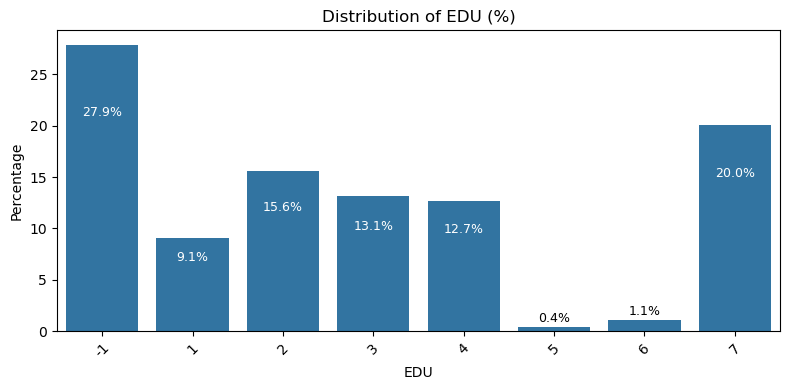




--- Proportions for SES ---
SES
 1    48.795151
-1    12.302628
 5    10.713802
 2     9.737862
 4     7.350932
 3     5.994708
 6     5.104917
Name: proportion, dtype: float64




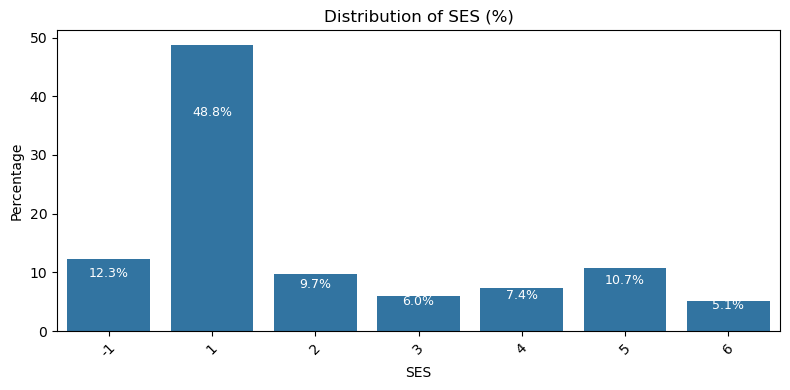

In [38]:
for col in clean_model_df.select_dtypes(include=['category']):
    print(f"--- Proportions for {col} ---")
    print(clean_model_df[col].value_counts(normalize=True) * 100)
    print("\n")

    plt.figure(figsize=(8, 4))
    
    proportions = clean_model_df[col].value_counts(normalize=True, dropna=False) * 100
    
    sns.barplot(x=proportions.index, y=proportions.values)
    
    plt.title(f'Distribution of {col} (%)')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    
    # Add labels on bars
    for i, val in enumerate(proportions[proportions.index.dropna()].sort_index().values):
        if val > 5:
            plt.text(i, val*0.75, f"{val:.1f}%", ha='center', fontsize=9, color="#FFFFFF")
        else:
            plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontsize=9, color="#000000")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n\n")

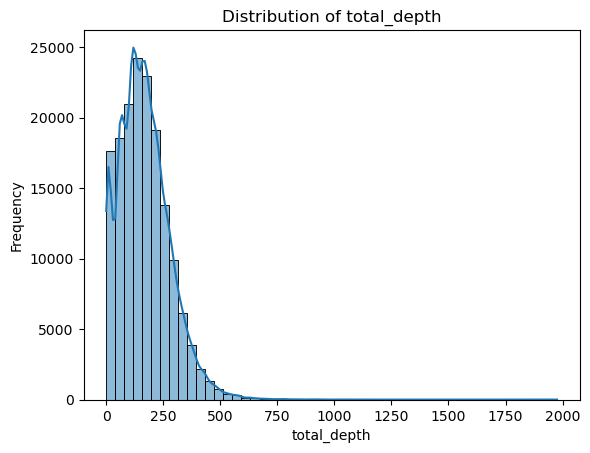

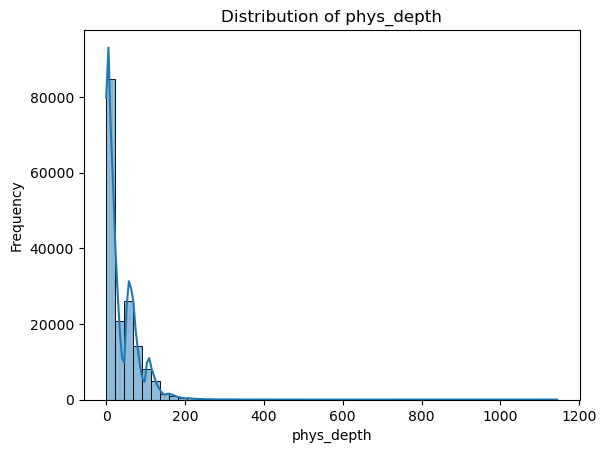

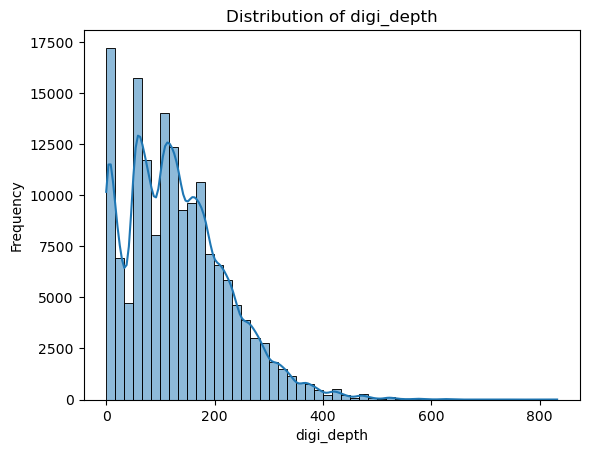

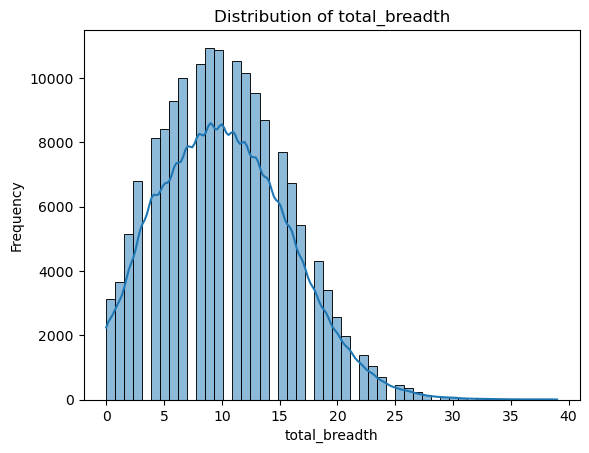

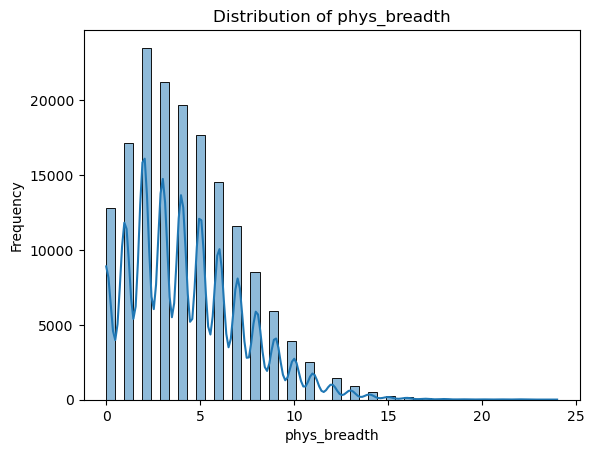

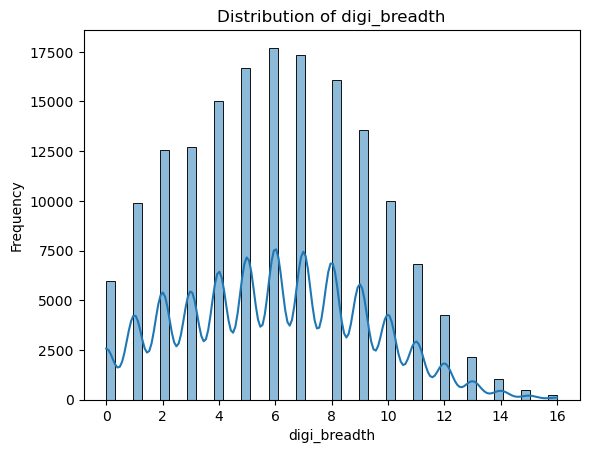

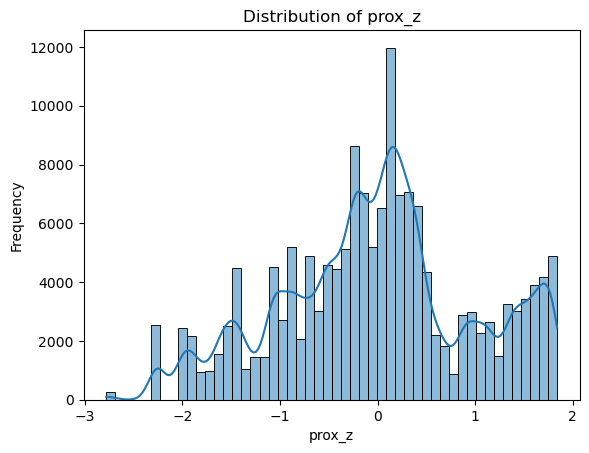

In [42]:
# Plot distributions
for col in clean_model_df.select_dtypes(include=['int', 'float']):
    plt.figure()
    sns.histplot(clean_model_df[col].dropna(), bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Model Construction

Model 0a: NULL - total_depth

Model 0b: NULL - total_breadth

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [13]:
# Null model with random intercept for LAD
model_0a = smf.mixedlm(
    "total_depth ~ 1",
    data=clean_model_df,
    groups=clean_model_df["LAD23CD"]
).fit()

print(model_0a.summary())

model_0b = smf.mixedlm(
    "total_breadth ~ 1",
    data=clean_model_df,
    groups=clean_model_df["LAD23CD"]
).fit()

print(model_0b.summary())


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: total_depth 
No. Observations: 162510  Method:             REML        
No. Groups:       296     Scale:              11938.0948  
Min. group size:  246     Log-Likelihood:     -993690.6712
Max. group size:  3395    Converged:          Yes         
Mean group size:  549.0                                   
----------------------------------------------------------
             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   169.881    0.821 207.014 0.000 168.273 171.490
Group Var   175.755    0.151                              

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: total_breadth
No. Observations: 162510  Method:             REML         
No. Groups:       296     Scale:              30.0293      
Min. group size:  246     Log-Likelihood:     -507480.0172 
Max. group si

In [22]:
# Extract variance components
def model_icc(model):
    var_lad = model.cov_re.iloc[0, 0]
    var_resid = model.scale

    ICC = var_lad / (var_lad + var_resid)

    return(ICC)

print("Dependent Variable: total_depth\nICC = ", "{:0.2f}%".format(model_icc(model_0a)*100))
print("Dependent Variable: total_breadth\nICC = ", "{:0.2f}%".format(model_icc(model_0b)*100))

Dependent Variable: total_depth
ICC =  1.45%
Dependent Variable: total_breadth
ICC =  3.52%


#### Proximity - Negative Binomial Model

Model 1a: total_depth ~ prox_z

Model 1b: total_breadth ~ prox_z

In [23]:
model_1a = smf.glm(
    formula="total_depth ~ prox_z",
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_1a.summary())

model_1b = smf.glm(
    formula="total_breadth ~ prox_z",
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_1b.summary())

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_depth   No. Observations:               162510
Model:                            GLM   Df Residuals:                   162508
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.9742e+05
Date:                Mon, 08 Jun 2026   Deviance:                   1.2346e+05
Time:                        14:47:35   Pearson chi2:                 6.78e+04
No. Iterations:                     5   Pseudo R-squ. (CS):          7.122e-08
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1346      0.002   2063.508      0.0

### Controls

Model 2a: total_depth ~ prox_z 
    + C(SEX) + C(AGE) + C(ETH)
    + C(EDU) + C(SES)

Model 2b: total_breadth ~ prox_z
    + C(SEX) + C(AGE) + C(ETH)
    + C(EDU) + C(SES)

In [25]:
model_2a = smf.glm(
    formula="""
    total_depth ~ prox_z
    + C(SEX) + C(AGE) + C(ETH)
    + C(EDU) + C(SES)
    """,
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_2a.summary())

model_2b = smf.glm(
    formula="""
    total_breadth ~ prox_z
    + C(SEX) + C(AGE) + C(ETH)
    + C(EDU) + C(SES)
    """,
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_2b.summary())

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_depth   No. Observations:               162510
Model:                            GLM   Df Residuals:                   162479
Model Family:        NegativeBinomial   Df Model:                           30
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.9466e+05
Date:                Mon, 08 Jun 2026   Deviance:                   1.1793e+05
Time:                        14:53:49   Pearson chi2:                 7.16e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.03341
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  5

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:          total_breadth   No. Observations:               162510
Model:                            GLM   Df Residuals:                   162479
Model Family:        NegativeBinomial   Df Model:                           30
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.4510e+05
Date:                Mon, 08 Jun 2026   Deviance:                       56394.
Time:                        14:53:51   Pearson chi2:                 4.30e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.04654
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [29]:
(np.exp(0.0115) - 1)*100

np.float64(1.1566379209598576)

In [28]:
(np.exp(0.0067) - 1)*100

np.float64(0.6722495211242352)